# Resting-state EEG topographic clustering

In [1]:
import matplotlib.pyplot as plt
import mne
import numpy as np
import os

from scipy.signal import find_peaks
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA

%matplotlib inline

## Read EEG data

In [2]:
# data_dir = "C:/Users/z3528600/OneDrive - UNSW/data/eeg/mpilmbb/pycrostates_2-20/data"
data_dir = r"/home/jjjyl/neuro-ml-proj/pycrostates_2-20/data"
files = os.listdir(data_dir)
files = [f for f in files if '_EC_' in f] # eyes-closed (EC) files only
subjects = np.unique([f.split('_')[0] for f in files])
print(f"Found n={len(subjects):d} subjects")
print(subjects)

Found n=201 subjects
['sub-010002' 'sub-010003' 'sub-010004' 'sub-010005' 'sub-010006'
 'sub-010007' 'sub-010010' 'sub-010012' 'sub-010016' 'sub-010017'
 'sub-010019' 'sub-010020' 'sub-010021' 'sub-010022' 'sub-010023'
 'sub-010024' 'sub-010026' 'sub-010027' 'sub-010028' 'sub-010029'
 'sub-010030' 'sub-010031' 'sub-010032' 'sub-010033' 'sub-010034'
 'sub-010035' 'sub-010036' 'sub-010037' 'sub-010038' 'sub-010039'
 'sub-010040' 'sub-010041' 'sub-010042' 'sub-010044' 'sub-010045'
 'sub-010046' 'sub-010047' 'sub-010048' 'sub-010049' 'sub-010050'
 'sub-010051' 'sub-010052' 'sub-010053' 'sub-010056' 'sub-010059'
 'sub-010060' 'sub-010061' 'sub-010062' 'sub-010063' 'sub-010064'
 'sub-010065' 'sub-010066' 'sub-010067' 'sub-010068' 'sub-010069'
 'sub-010070' 'sub-010071' 'sub-010072' 'sub-010073' 'sub-010074'
 'sub-010075' 'sub-010076' 'sub-010079' 'sub-010080' 'sub-010081'
 'sub-010083' 'sub-010084' 'sub-010085' 'sub-010086' 'sub-010088'
 'sub-010089' 'sub-010090' 'sub-010091' 'sub-010092' 's

In [3]:
subj = "sub-010067" # which subject
i_ep = 0 # which epoch?
fname = f"{data_dir:s}/{subj:s}_EC_avgref_1-30Hz_ep{i_ep:02d}_raw.fif"
print(f"Filename: {fname:s}")
if os.path.isfile(fname):
    print(f"OK, file exists...")
else:
    print("This file does not exist...")

Filename: /home/jjjyl/neuro-ml-proj/pycrostates_2-20/data/sub-010067_EC_avgref_1-30Hz_ep00_raw.fif
OK, file exists...


In [4]:
raw = mne.io.read_raw(fname, preload=True)
#raw.set_eeg_reference(['Cz'])

Opening raw data file /home/jjjyl/neuro-ml-proj/pycrostates_2-20/data/sub-010067_EC_avgref_1-30Hz_ep00_raw.fif...
    Range : 0 ... 15970 =      0.000 ...    63.880 secs
Ready.
Reading 0 ... 15970  =      0.000 ...    63.880 secs...


Using matplotlib as 2D backend.


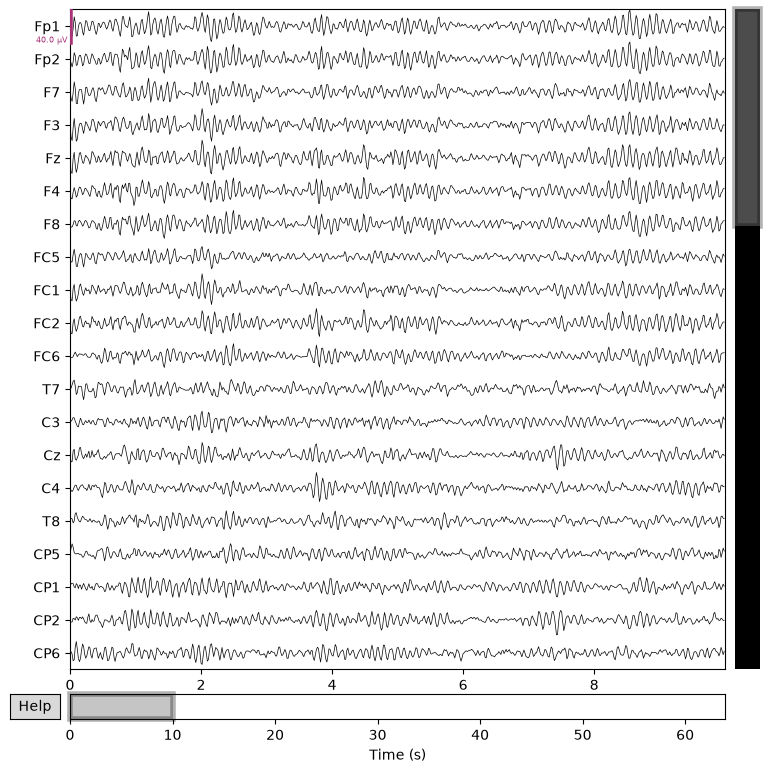

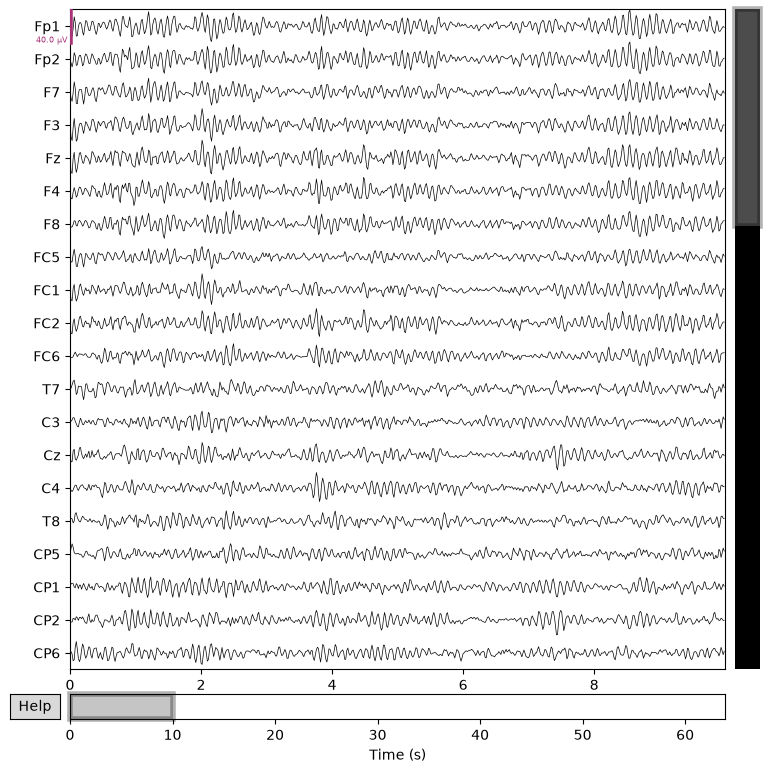

In [5]:
raw.plot()

## Extract clustering data at GFP peaks

In [6]:
data = raw.get_data()
print(data.shape)

(61, 15971)


In [7]:
gfp = np.std(data, axis=0)
print(gfp.shape)

(15971,)


In [8]:
gfp_peak_indices, gfp_peak_props = find_peaks(
    gfp, 
    height=np.min(gfp),       # Minimum absolute height required for a peak
    distance=5,       # Minimum horizontal distance (in samples) between peaks
    prominence=0.    # How much a peak stands out relative to its surroundings
)
print(f"Number of GFP peaks detected: {len(gfp_peak_indices):d}")

Number of GFP peaks detected: 1367


Sampling rate: 250.0 Hz, dt=4.0 ms


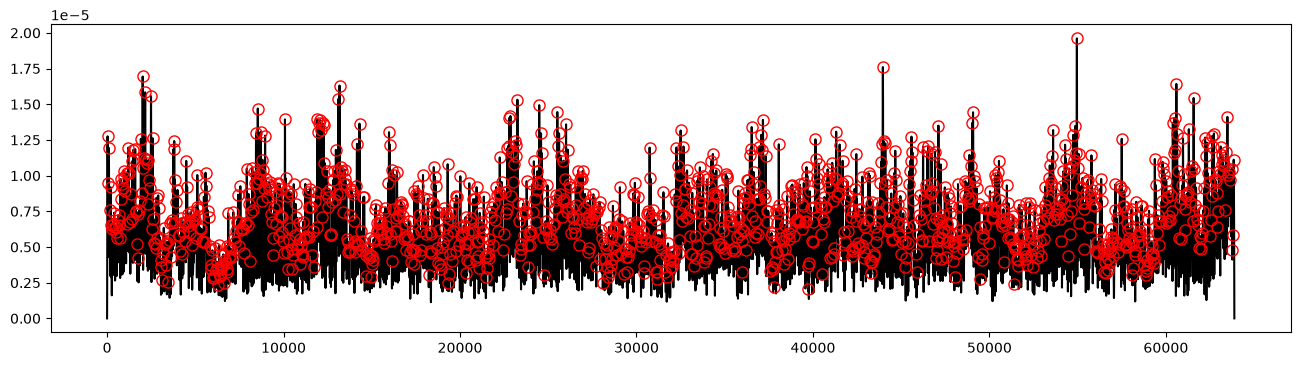

In [9]:
fs = raw.info['sfreq'] # sampling rate
dt = 1000/fs # sampling interval in ms
print(f"Sampling rate: {fs:.1f} Hz, dt={dt:.1f} ms")
time = dt*np.arange(data.shape[1])
plt.figure(figsize=(16,4))
plt.plot(time, gfp, '-k')
plt.plot(time[gfp_peak_indices], gfp[gfp_peak_indices], 'or', ms=8, mfc='none')
plt.show()

In [10]:
X = data[:,gfp_peak_indices].T
print(f"Clustering data X shape: ", X.shape)

Clustering data X shape:  (1367, 61)


In [ ]:
# save GFP peak data as files, otherwise repeat processing every time for each data file 
import pathlib
batch_data_dir = pathlib.Path("/home/jjjyl/neuro-ml-proj/pycrostates_2-20/data")
recording_files = sorted(batch_data_dir.glob("sub-*_EC_avgref_1-30Hz_ep*_raw.fif"))
batch_subjects = {fif_file.name.split("_")[0] for fif_file in recording_files}

gfp_peaks_dir = batch_data_dir / "gfp_peaks"
gfp_peaks_dir.mkdir(parents=True, exist_ok=True)

gfp_peaks_dir = batch_data_dir / "gfp_peaks"

for file in recording_files:
    gfp_peak_file = gfp_peaks_dir / (file.stem + "_gfp_peaks.npy")
    gfp_peak_indices, gfp_peak_props = find_peaks(
    gfp, 
    height=np.min(gfp),       # Minimum absolute height required for a peak
    distance=5,       # Minimum horizontal distance (in samples) between peaks
    prominence=0.    # How much a peak stands out relative to its surroundings
    )
    np.save(gfp_peak_file, gfp_peak_indices)


## HDBScan clustering

### Polarised (standard)

In [11]:
# min_cluster_size is the main lever on how many clusters HDBSCAN finds:
# smaller -> more, finer-grained clusters; larger -> fewer, coarser clusters.
min_cluster_sizes = [3, 5, 7, 8, 10, 20, 30, 50, 100, 150, 200]

# print(f"{'min_cluster_size':>17s}  {'n_clusters':>10s}  {'n_noise':>8s}")
# for mcs in min_cluster_sizes:
#     hdb_sweep_pol = HDBSCAN(copy=True, min_cluster_size=mcs)
#     hdb_sweep_pol.fit(X)
#     sweep_labels_pol = hdb_sweep_pol.labels_
#     n_clusters_sweep_pol = len(np.unique(sweep_labels_pol[sweep_labels_pol > -1]))
#     n_noise_pol = np.sum(sweep_labels_pol == -1)
#     print(f"{mcs:>17d}  {n_clusters_sweep_pol:>10d}  {n_noise_pol:>8d}")

print(f"{'min_cluster_size':>17s}  {'n_clusters':>10s}  {'n_noise':>8s}")
for mcs in min_cluster_sizes:
    hdb_sweep = HDBSCAN(copy=True, min_cluster_size=mcs)
    hdb_sweep.fit(X)
    sweep_labels = hdb_sweep.labels_
    n_clusters_sweep = len(np.unique(sweep_labels[sweep_labels > -1]))
    n_noise = np.sum(sweep_labels == -1)
    print(f"{mcs:>17d}  {n_clusters_sweep:>10d}  {n_noise:>8d}")

 min_cluster_size  n_clusters   n_noise
                3           2       146
                5           4       904
                7           2      1051
                8           3      1040
               10           2      1058
               20           2       938
               30           2      1045
               50           2      1025
              100           0      1367
              150           0      1367
              200           0      1367


In [12]:
mcs_selected_pol = 20
hdb_pol = HDBSCAN(copy=True, min_cluster_size=mcs_selected_pol)
hdb_pol.fit(X)
labels_pol = hdb_pol.labels_
unique_labels_pol = np.unique(labels_pol)
n_clusters_pol = len(np.unique(labels_pol[labels_pol > -1]))
n_noise_pol = np.sum(labels_pol == -1)
print(f"{mcs_selected_pol:>17d}  {n_clusters_pol:>10d}  {n_noise_pol:>8d}")

               20           2       938


### Polarity-invariant metric

In [34]:
# Polarity-invariant distance: topographies +v and -v represent the same microstate, so treat them as identical (distance 0).
from scipy.spatial.distance import cosine

def polarity_invariant_distance(u, v):
    correlation = 1 - cosine(u, v)
    return 1 - correlation ** 2

#### Sweep `min_cluster_size` to see effect on cluster count

In [25]:
# Sweep using the polarity-invariant metric, for comparison against the
# standard Euclidean metric swept above.
print(f"{'min_cluster_size':>17s}  {'n_clusters':>10s}  {'n_noise':>8s}")
for mcs in min_cluster_sizes:
    hdb_sweep = HDBSCAN(copy=True, min_cluster_size=mcs, metric=polarity_invariant_distance, algorithm='brute', allow_single_cluster=True)
    hdb_sweep.fit(X)
    sweep_labels = hdb_sweep.labels_
    n_clusters_sweep = len(np.unique(sweep_labels[sweep_labels > -1]))
    n_noise = np.sum(sweep_labels == -1)
    print(f"{mcs:>17d}  {n_clusters_sweep:>10d}  {n_noise:>8d}")

 min_cluster_size  n_clusters   n_noise
                3           1         0
                5           1         0
                7           1         0
                8           1         0
               10           1         0
               20           1         0
               30           1         0
               50           1         0
              100           1         0
              150           1         0
              200           1         0


In [15]:
mcs_selected = 20
hdb = HDBSCAN(copy=True, min_cluster_size=mcs_selected, metric=polarity_invariant_distance, algorithm='brute', allow_single_cluster=True)
hdb.fit(X)
labels = hdb.labels_
unique_labels = np.unique(labels)
n_unique_labels = len(unique_labels)
n_clusters = len(np.unique(labels[labels > -1]))
n_noise = np.sum(labels == -1)
print(f"{mcs:>17d}  {n_clusters:>10d}  {n_noise:>8d}")

              200           1      1347


## Project on 2D PCA

In [16]:
do_PCA = True

if do_PCA:
    pca = PCA(n_components=2)
    pca.fit(X)
    X2d = pca.transform(X) # transform GFP peaks
else:
    X2d = X
print(X2d.shape)

(1367, 2)


Polarised: n_noise=938, n_clustered=429
Polarity-invariant: n_noise=1347, n_clustered=20


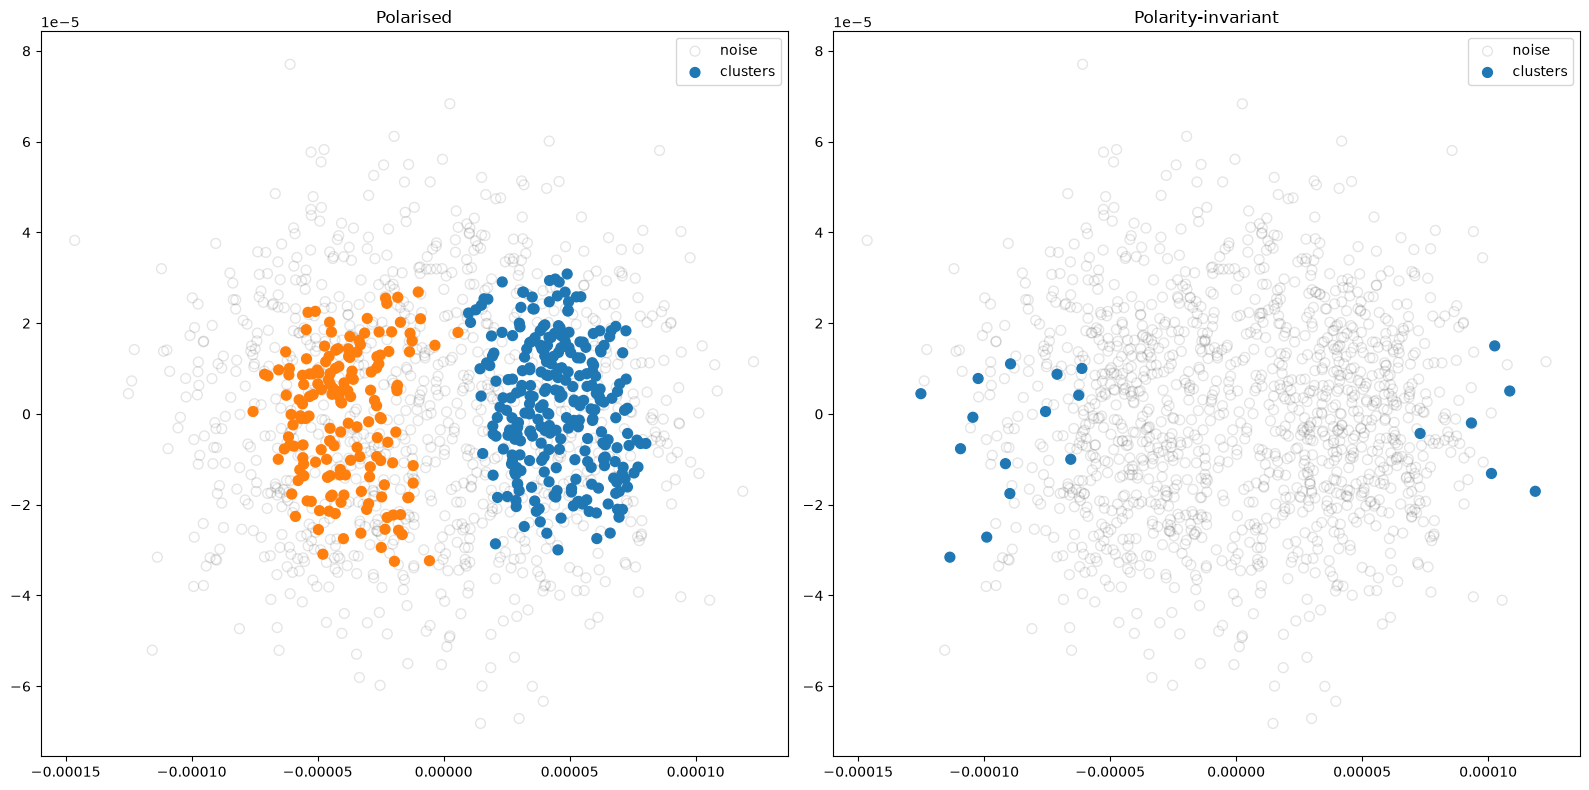

In [17]:
# Qualitative colormap for good categorical contrast between clusters
# (tab10/tab20 are designed for this, unlike hsv whose evenly-spaced hues
# aren't perceptually uniform). Noise (-1) is handled separately below.
def plot_pca_projection(ax, labels_to_plot, unique_labels_to_plot, title):
    n_unique = len(unique_labels_to_plot)
    N = n_unique - 1 if -1 in unique_labels_to_plot else n_unique
    if N <= 10:
        colors = plt.colormaps['tab10'](np.arange(N))
    elif N <= 20:
        colors = plt.colormaps['tab20'](np.arange(N))
    else:
        colors = plt.colormaps['hsv'](np.linspace(0, 1, N))

    noise_mask = labels_to_plot == -1
    print(f"{title}: n_noise={np.sum(noise_mask):d}, n_clustered={np.sum(~noise_mask):d}")

    # noise: empty markers, black edge
    ax.scatter(X2d[noise_mask, 0], X2d[noise_mask, 1],
               facecolors='none', edgecolors='black', s=50,
               alpha=0.1, label='noise')

    # clustered points: filled with their cluster's color
    cluster_colors = [colors[k] for k in labels_to_plot[~noise_mask]]
    ax.scatter(X2d[~noise_mask, 0], X2d[~noise_mask, 1],
               c=cluster_colors, s=50, label='clusters')

    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_pca_projection(axes[0], labels_pol, unique_labels_pol, 'Polarised')
plot_pca_projection(axes[1], labels, unique_labels, 'Polarity-invariant')
fig.tight_layout()
plt.show()

## Cluster centroid topographies

### Polarised topographies (main workflow)


Centroids shape: (2, 61)


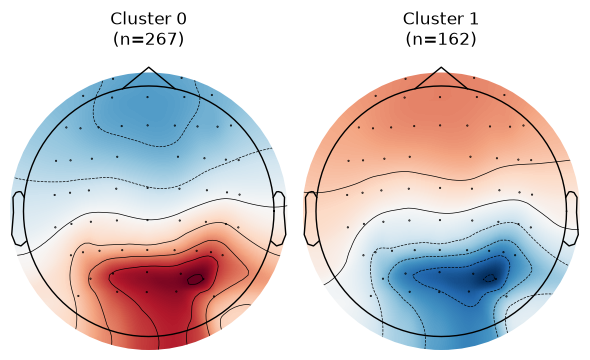

In [18]:
# Cluster centroid = mean sensor-space topography of GFP-peak samples assigned
# to that cluster (noise, label -1, excluded).
cluster_labels_sorted = np.unique(labels_pol[labels_pol > -1])
K = len(cluster_labels_sorted)
centroids = np.array([X[labels_pol == k].mean(axis=0) for k in cluster_labels_sorted])
print(f"Centroids shape: {centroids.shape}")  # (K, n_channels)

fig, axes = plt.subplots(1, K, figsize=(3 * K, 3.5))
if K == 1:
    axes = [axes]

for k, centroid, ax in zip(cluster_labels_sorted, centroids, axes):
    mne.viz.plot_topomap(centroid, raw.info, axes=ax, show=False)
    ax.set_title(f"Cluster {k:d}\n(n={np.sum(labels_pol == k):d})")

fig.tight_layout()
plt.show()

### Ignored-polarity topographies


Centroids shape: (1, 61)


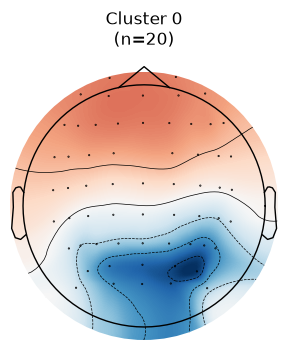

In [ ]:
# Optional: polarity-invariant centroid topographies.
# This keeps the main polarised workflow unchanged and tests the alternative
# interpretation that +A and -A are the same microstate.
X_pol_inv = X.copy()
cluster_labels_sorted = np.unique(labels[labels > -1])
K = len(cluster_labels_sorted)
centroids = np.array([X_pol_inv[labels == k].mean(axis=0) for k in cluster_labels_sorted])
print(f"Centroids shape: {centroids.shape}")  # (K, n_channels)

for k, centroid in zip(cluster_labels_sorted, centroids):
    cluster_mask = labels == k
    cluster_samples = X_pol_inv[cluster_mask]
    dot_products = np.dot(cluster_samples, centroid)
    X_pol_inv[cluster_mask] *= np.sign(dot_products)[:, np.newaxis]

centroids = np.array([X_pol_inv[labels == k].mean(axis=0) for k in cluster_labels_sorted])

fig, axes = plt.subplots(1, K, figsize=(3 * K, 3.5))
if K == 1:
    axes = [axes]

for k, centroid, ax in zip(cluster_labels_sorted, centroids, axes):
    mne.viz.plot_topomap(centroid, raw.info, axes=ax, show=False)
    ax.set_title(f"Cluster {k:d}\n(n={np.sum(labels == k):d})")

fig.tight_layout()
plt.show()

# Plotting all data

In [50]:
# Polarity-invariant HDBSCAN sweep for every eyes-closed epoch of each subject.
from pathlib import Path
import gc

min_cluster_sizes = [3, 5, 7, 8, 10, 20, 30, 50, 100, 150, 200]

batch_data_dir = Path("/home/jjjyl/neuro-ml-proj/pycrostates_2-20/data")
recording_files = sorted(batch_data_dir.glob("sub-*_EC_avgref_1-30Hz_ep*_raw.fif"))
batch_subjects = {fif_file.name.split("_")[0] for fif_file in recording_files}
print(f"Found {len(batch_subjects)} subjects and {len(recording_files)} EC epochs.")

batch_results_polarity_invariant = []
for fif_file in recording_files:
    subject = fif_file.name.split("_")[0]
    epoch = fif_file.stem.split("_")[-2]
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    subject_data = raw.get_data()
    subject_gfp = np.std(subject_data, axis=0)
    subject_peak_indices, _ = find_peaks(subject_gfp)
    subject_topographies = subject_data[:, subject_peak_indices].T

    print(f"\n{subject} {epoch}")
    print(f"{'min_cluster_size':>17s}  {'n_clusters':>10s}  {'n_noise':>8s}")
    for mcs in min_cluster_sizes:
        hdb_sweep = HDBSCAN(
            copy=True,
            min_cluster_size=mcs,
            metric=polarity_invariant_distance,
            allow_single_cluster=True,
        ).fit(subject_topographies)
        sweep_labels = hdb_sweep.labels_
        n_clusters_sweep = len(np.unique(sweep_labels[sweep_labels >= 0]))
        n_noise = int(np.sum(sweep_labels == -1))
        print(f"{mcs:>17d}  {n_clusters_sweep:>10d}  {n_noise:>8d}")
        batch_results_polarity_invariant.append(
            {
                "subject": subject,
                "epoch": epoch,
                "min_cluster_size": mcs,
                "n_peaks": len(sweep_labels),
                "n_clusters": n_clusters_sweep,
                "n_noise": n_noise,
            }
        )
        del hdb_sweep, sweep_labels

    del raw, subject_data, subject_gfp, subject_peak_indices, subject_topographies
    gc.collect()

batch_results_polarity_invariant

Found 201 subjects and 1383 EC epochs.

sub-010002 ep00
 min_cluster_size  n_clusters   n_noise
                3           1       438
                5           1      1021
                7           1      1682
                8           1      1685
               10           1      1762
               20           1      1752
               30           1      1742
               50           1      1722
              100           1      1672
              150           1      1622
              200           1      1572

sub-010002 ep01
 min_cluster_size  n_clusters   n_noise
                3           1       127
                5           1      1565
                7           1      1621
                8           1      1621
               10           1      1681
               20           1      1747
               30           1      1736
               50           1      1717
              100           1      1667
              150           1      1617
       

KeyboardInterrupt: 

In [ ]:
# Polarity-sensitive HDBSCAN sweep for every eyes-closed epoch of each subject.
batch_results_polarity_sensitive = []
for fif_file in recording_files:
    subject = fif_file.name.split("_")[0]
    epoch = fif_file.stem.split("_")[-2]
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    subject_data = raw.get_data()
    subject_gfp = np.std(subject_data, axis=0)
    subject_peak_indices, _ = find_peaks(subject_gfp)
    subject_topographies = subject_data[:, subject_peak_indices].T

    print(f"\n{subject} {epoch}")
    print(f"{'min_cluster_size':>17s}  {'n_clusters':>10s}  {'n_noise':>8s}")
    for mcs in min_cluster_sizes:
        hdb_sweep = HDBSCAN(copy=True, min_cluster_size=mcs, single_cluster_mode="allow").fit(subject_topographies)
        sweep_labels = hdb_sweep.labels_
        n_clusters_sweep = len(np.unique(sweep_labels[sweep_labels >= 0]))
        n_noise = int(np.sum(sweep_labels == -1))
        print(f"{mcs:>17d}  {n_clusters_sweep:>10d}  {n_noise:>8d}")
        batch_results_polarity_sensitive.append(
            {
                "subject": subject,
                "epoch": epoch,
                "min_cluster_size": mcs,
                "n_peaks": len(sweep_labels),
                "n_clusters": n_clusters_sweep,
                "n_noise": n_noise,
            }
        )
        del hdb_sweep, sweep_labels

    del raw, subject_data, subject_gfp, subject_peak_indices, subject_topographies
    gc.collect()

batch_results_polarity_sensitive


sub-010002 ep00
 min_cluster_size  n_clusters   n_noise
                3           2       179
                5           7      1530
                7           4      1615
                8           3      1623
               10           2      1679
               20           2      1656
               30           0      1772
               50           0      1772
              100           0      1772
              150           0      1772
              200           0      1772

sub-010002 ep01
 min_cluster_size  n_clusters   n_noise
                3           3       128
                5           2      1555
                7           2      1607
                8           3      1669
               10           3      1714
               20           0      1767
               30           0      1767
               50           0      1767
              100           0      1767
              150           0      1767
              200           0      1767

sub-0

[{'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 3,
  'n_peaks': 1772,
  'n_clusters': 2,
  'n_noise': 179},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 5,
  'n_peaks': 1772,
  'n_clusters': 7,
  'n_noise': 1530},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 7,
  'n_peaks': 1772,
  'n_clusters': 4,
  'n_noise': 1615},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 8,
  'n_peaks': 1772,
  'n_clusters': 3,
  'n_noise': 1623},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 10,
  'n_peaks': 1772,
  'n_clusters': 2,
  'n_noise': 1679},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 20,
  'n_peaks': 1772,
  'n_clusters': 2,
  'n_noise': 1656},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 30,
  'n_peaks': 1772,
  'n_clusters': 0,
  'n_noise': 1772},
 {'subject': 'sub-010002',
  'epoch': 'ep00',
  'min_cluster_size': 50,
  'n_peaks': 1772,
  'n

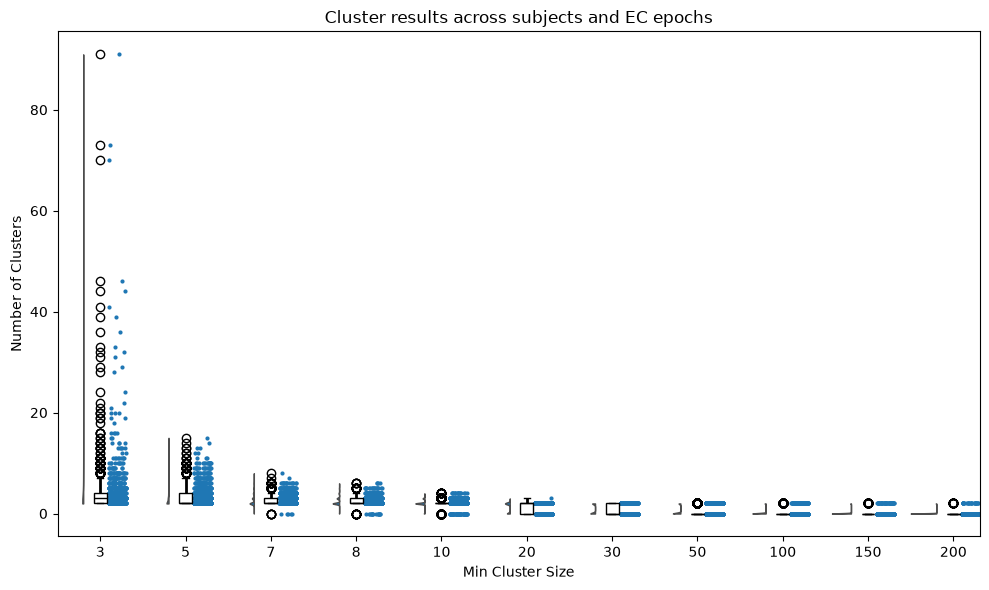

In [ ]:
# Visualize cluster results for polarity-sensitive HDBSCAN
#  x-axis: min_cluster_size, y_axis: n_clusters (for 201 subjects), raincloud plot
import matplotlib.pyplot as plt
import pandas as pd
import ptitprince as pt

df = pd.DataFrame(batch_results_polarity_sensitive)

# min_cluster_size as a category, not a continuous numeric axis
order = sorted(df["min_cluster_size"].unique())
df["min_cluster_size"] = pd.Categorical(
  df["min_cluster_size"],
  categories=order,
  ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 6))

pt.RainCloud(
  data=df,
  x="min_cluster_size",
  y="n_clusters",
  orient="v",       # x = category, y = value
  width_viol=0.6,
  move=0.2,
  pointplot=False,
  ax=ax,
)

ax.set_title("Cluster results across subjects and EC epochs")
ax.set_xlabel("Min Cluster Size")
ax.set_ylabel("Number of Clusters")
plt.tight_layout()
plt.show()

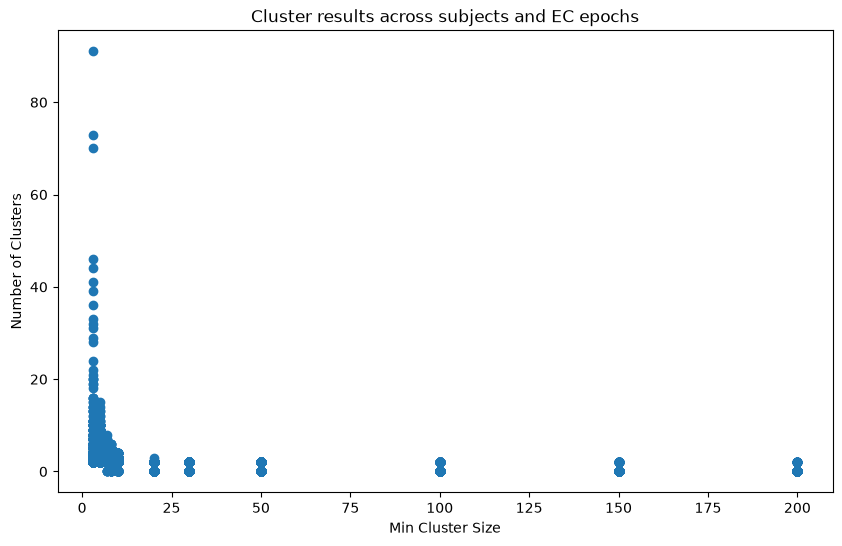

In [47]:
# scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["min_cluster_size"], df["n_clusters"])
plt.xlabel("Min Cluster Size")
plt.ylabel("Number of Clusters")
plt.title("Cluster results across subjects and EC epochs")
plt.show()

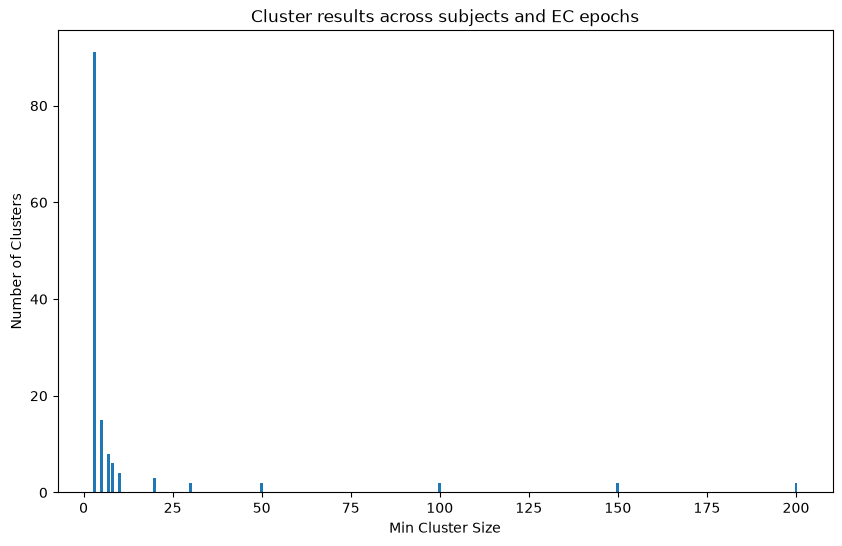

In [49]:
#  bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df["min_cluster_size"], df["n_clusters"])
plt.xlabel("Min Cluster Size")
plt.ylabel("Number of Clusters")
plt.title("Cluster results across subjects and EC epochs")
plt.show()

# Visualising polarity-agnostic clusters

In [ ]:
df = pd.DataFrame(batch_results_polarity_invariant)

# min_cluster_size as a category, not a continuous numeric axis
order = sorted(df["min_cluster_size"].unique())
df["min_cluster_size"] = pd.Categorical(
  df["min_cluster_size"],
  categories=order,
  ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 6))

pt.RainCloud(
  data=df,
  x="min_cluster_size",
  y="n_clusters",
  orient="v",
  width_viol=0.6,
  move=0.2,
  pointplot=False,
  ax=ax,
)

ax.set_title("Cluster results across subjects and EC epochs")
ax.set_xlabel("Min Cluster Size")
ax.set_ylabel("Number of Clusters")
plt.tight_layout()
plt.show()